In [1]:
import pandas as pd
from pathlib import Path

DATA_PATH = Path("../data/raw/PJMW_MW_Hourly (2).xlsx")

df = pd.read_excel(DATA_PATH)

print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

display(df.head())

Dataset shape: (143206, 2)

Columns:
['Datetime', 'PJMW_MW']


,Datetime,PJMW_MW
0,2002-12-31 01:00:00,5077
1,2002-12-31 02:00:00,4939
2,2002-12-31 03:00:00,4885
3,2002-12-31 04:00:00,4857
4,2002-12-31 05:00:00,4930


In [2]:
print("Data types:")
display(df.dtypes)

print("\nMissing values:")
display(df.isna().sum())

print("\nDuplicate rows:", df.duplicated().sum())

Data types:


Datetime    datetime64[ns]
PJMW_MW              int64
dtype: object


Missing values:


Datetime    0
PJMW_MW     0
dtype: int64


Duplicate rows: 0


In [3]:
print("Start date:", df["Datetime"].min())
print("End date:", df["Datetime"].max())

print("\nNumber of records:", len(df))

print("\nChronologically sorted:", df["Datetime"].is_monotonic_increasing)

print("\nDuplicate timestamps:", df["Datetime"].duplicated().sum())

Start date: 2002-04-01 01:00:00
End date: 2018-08-03 00:00:00

Number of records: 143206

Chronologically sorted: False

Duplicate timestamps: 4


In [4]:
duplicate_timestamps = df[df["Datetime"].duplicated(keep=False)].sort_values("Datetime")

display(duplicate_timestamps)

,Datetime,PJMW_MW
104424,2014-11-02 02:00:00,4613
104425,2014-11-02 02:00:00,4571
113208,2015-11-01 02:00:00,3927
113209,2015-11-01 02:00:00,3832
121848,2016-11-06 02:00:00,4114
121849,2016-11-06 02:00:00,4089
130656,2017-11-05 02:00:00,4042
130657,2017-11-05 02:00:00,3984


In [5]:
df = df.sort_values("Datetime").reset_index(drop=True)

print("Chronologically sorted:", df["Datetime"].is_monotonic_increasing)
print("Duplicate timestamps:", df["Datetime"].duplicated().sum())

Chronologically sorted: True
Duplicate timestamps: 4


In [6]:
time_diff = df["Datetime"].diff().dropna()

print("Most common time interval:")
print(time_diff.value_counts().head())

print("\nIntervals other than 1 hour:")
print((time_diff != pd.Timedelta(hours=1)).sum())

Most common time interval:
Datetime
0 days 01:00:00    143171
0 days 02:00:00        30
0 days 00:00:00         4
Name: count, dtype: int64

Intervals other than 1 hour:
34


In [7]:
two_hour_gaps = df.loc[
    df["Datetime"].diff() == pd.Timedelta(hours=2),
    ["Datetime", "PJMW_MW"]
]

display(two_hour_gaps)

,Datetime,PJMW_MW
146,2002-04-07 04:00:00,4871
5016,2002-10-27 03:00:00,4014
8880,2003-04-06 04:00:00,4376
13750,2003-10-26 03:00:00,4027
17614,2004-04-04 04:00:00,4691
22652,2004-10-31 03:00:00,4006
26348,2005-04-03 04:00:00,5026
31386,2005-10-30 03:00:00,4673
35082,2006-04-02 04:00:00,3721
40120,2006-10-29 03:00:00,4367


In [8]:
df.loc[
    (df["Datetime"] >= "2010-12-09 22:00:00") &
    (df["Datetime"] <= "2010-12-10 05:00:00"),
    ["Datetime", "PJMW_MW"]
]

,Datetime,PJMW_MW
76179,2010-12-09 22:00:00,7354
76180,2010-12-09 23:00:00,6972
76181,2010-12-10 01:00:00,6280
76182,2010-12-10 02:00:00,6117
76183,2010-12-10 03:00:00,6035
76184,2010-12-10 04:00:00,6036
76185,2010-12-10 05:00:00,6079


In [9]:
print("Minimum consumption:", df["PJMW_MW"].min(), "MW")
print("Maximum consumption:", df["PJMW_MW"].max(), "MW")
print("Mean consumption:", round(df["PJMW_MW"].mean(), 2), "MW")
print("Median consumption:", df["PJMW_MW"].median(), "MW")

print("\nDescriptive statistics:")
display(df["PJMW_MW"].describe())

Minimum consumption: 487 MW
Maximum consumption: 9594 MW
Mean consumption: 5602.38 MW
Median consumption: 5530.0 MW

Descriptive statistics:


count    143206.000000
mean       5602.375089
std         979.142872
min         487.000000
25%        4907.000000
50%        5530.000000
75%        6252.000000
max        9594.000000
Name: PJMW_MW, dtype: float64

In [10]:
yearly_summary = (
    df.assign(Year=df["Datetime"].dt.year)
      .groupby("Year")["PJMW_MW"]
      .agg(["count", "mean", "min", "max"])
      .round(2)
)

display(yearly_summary)

,count,mean,min,max
Year,,,,
2002,6597,5621.66,3621,8300
2003,8758,5700.63,487,8437
2004,8782,5866.62,3793,8598
2005,8758,6038.41,3837,8823
2006,8758,5425.45,3428,8734
2007,8758,5635.40,3466,8664
2008,8782,5530.13,3436,8426
2009,8758,5290.56,3213,8541
2010,8757,5573.03,3276,8620


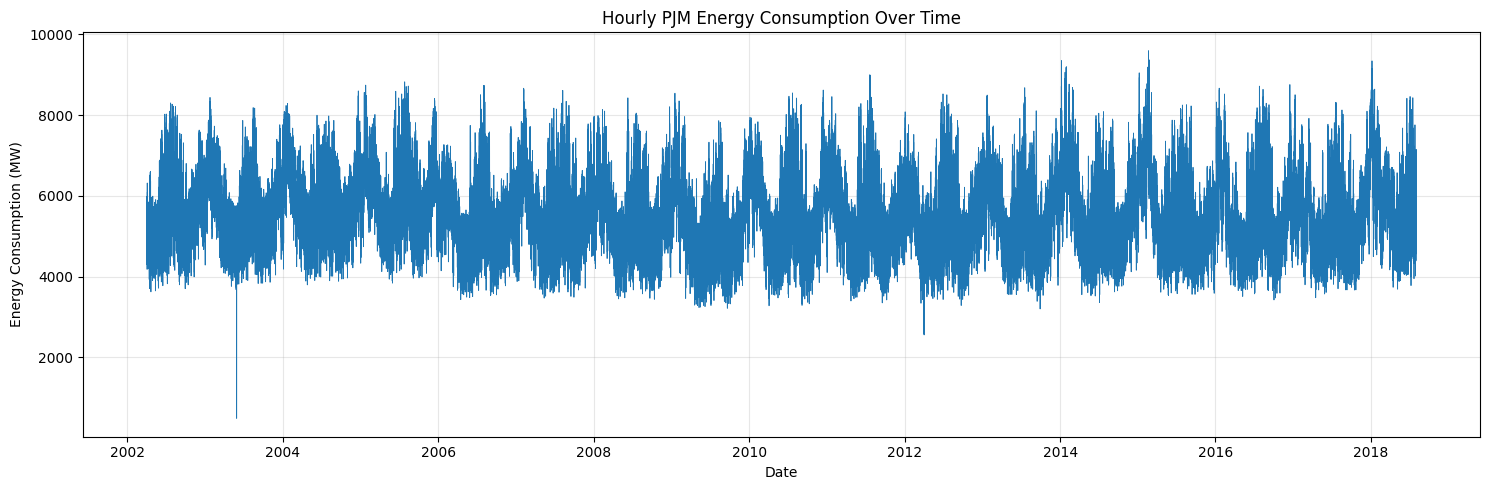

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 5))

plt.plot(
    df["Datetime"],
    df["PJMW_MW"],
    linewidth=0.6
)

plt.title("Hourly PJM Energy Consumption Over Time")
plt.xlabel("Date")
plt.ylabel("Energy Consumption (MW)")
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

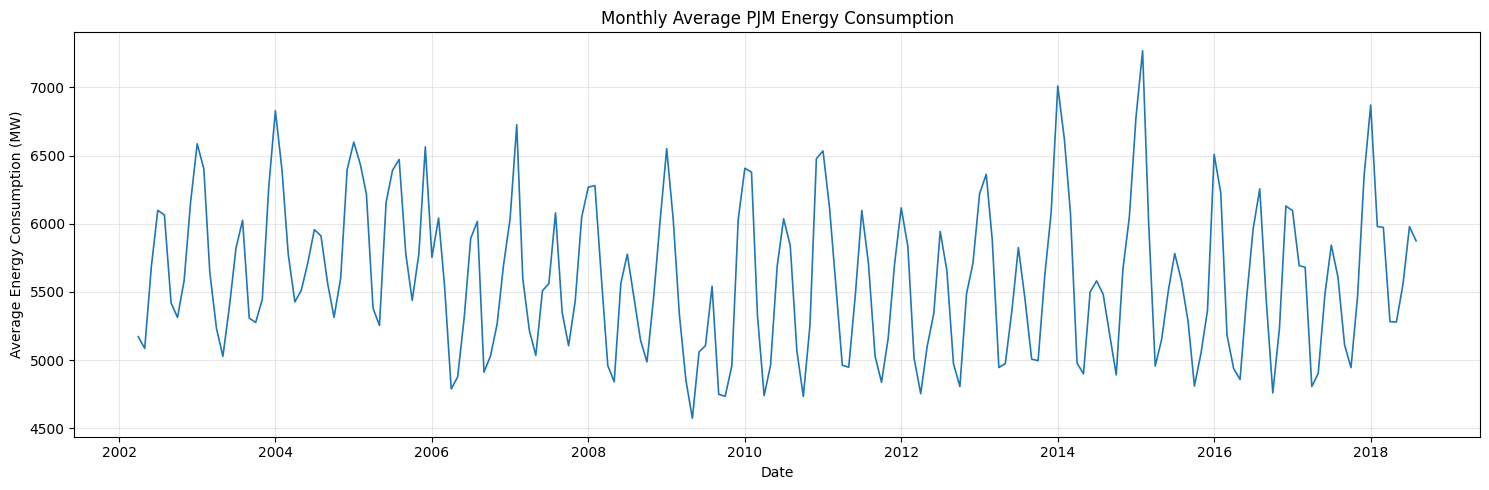

In [12]:
monthly_consumption = (
    df.set_index("Datetime")["PJMW_MW"]
      .resample("MS")
      .mean()
)

plt.figure(figsize=(15, 5))

plt.plot(
    monthly_consumption.index,
    monthly_consumption.values,
    linewidth=1.2
)

plt.title("Monthly Average PJM Energy Consumption")
plt.xlabel("Date")
plt.ylabel("Average Energy Consumption (MW)")
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

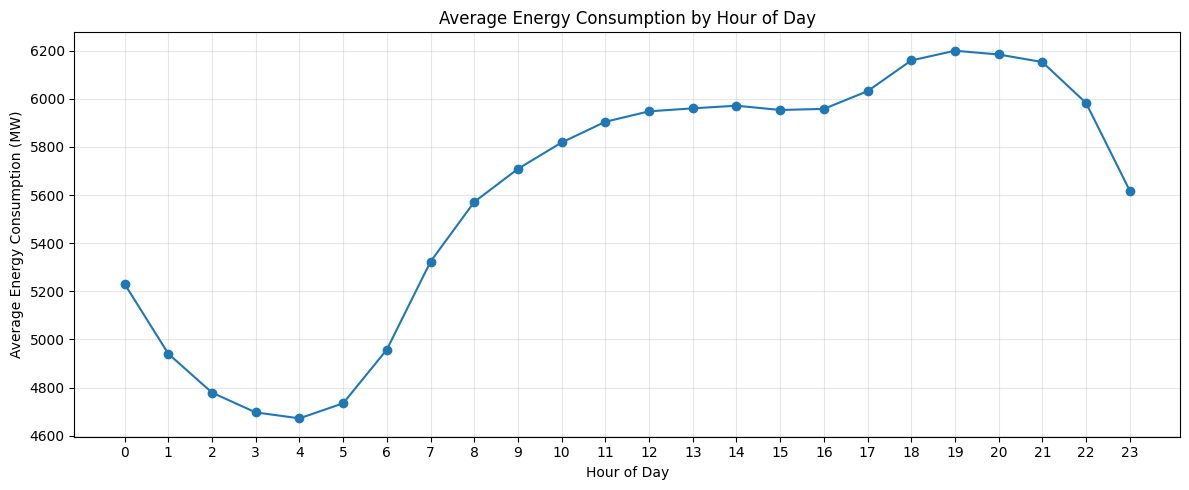

In [13]:
hourly_profile = (
    df.groupby(df["Datetime"].dt.hour)["PJMW_MW"]
      .mean()
)

plt.figure(figsize=(12, 5))

plt.plot(
    hourly_profile.index,
    hourly_profile.values,
    marker="o"
)

plt.title("Average Energy Consumption by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Average Energy Consumption (MW)")
plt.xticks(range(24))
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

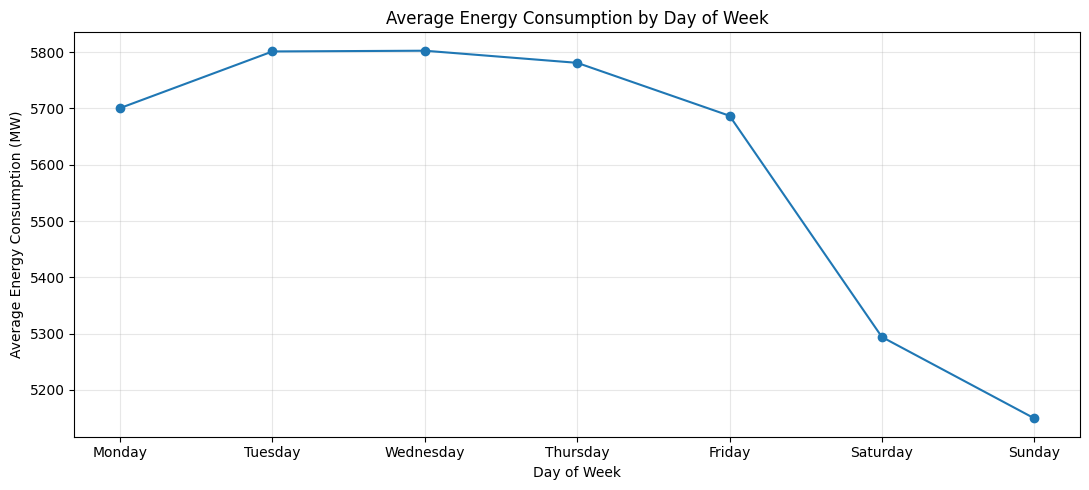

In [14]:
day_profile = (
    df.assign(DayOfWeek=df["Datetime"].dt.day_name())
      .groupby("DayOfWeek")["PJMW_MW"]
      .mean()
      .reindex([
          "Monday",
          "Tuesday",
          "Wednesday",
          "Thursday",
          "Friday",
          "Saturday",
          "Sunday"
      ])
)

plt.figure(figsize=(11, 5))

plt.plot(
    day_profile.index,
    day_profile.values,
    marker="o"
)

plt.title("Average Energy Consumption by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Energy Consumption (MW)")
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

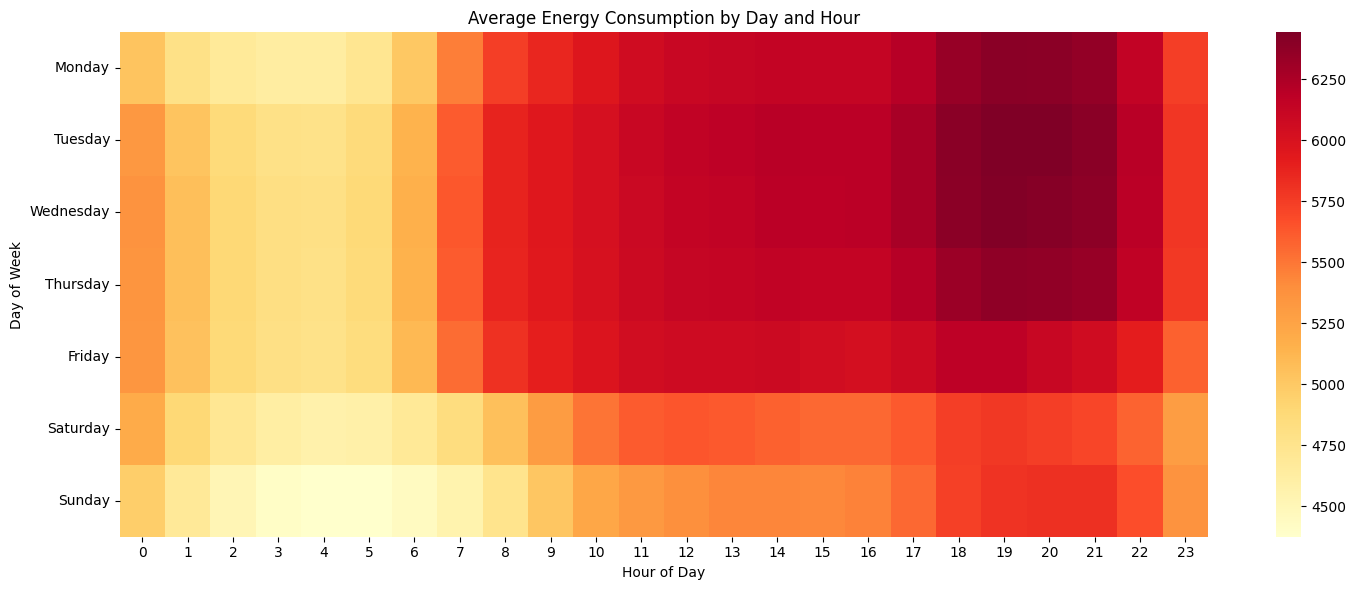

In [15]:
import seaborn as sns

heatmap_data = (
    df.assign(
        DayOfWeek=df["Datetime"].dt.day_name(),
        Hour=df["Datetime"].dt.hour
    )
    .pivot_table(
        index="DayOfWeek",
        columns="Hour",
        values="PJMW_MW",
        aggfunc="mean"
    )
    .reindex([
        "Monday",
        "Tuesday",
        "Wednesday",
        "Thursday",
        "Friday",
        "Saturday",
        "Sunday"
    ])
)

plt.figure(figsize=(15, 6))

sns.heatmap(
    heatmap_data,
    cmap="YlOrRd",
    annot=False
)

plt.title("Average Energy Consumption by Day and Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Day of Week")
plt.tight_layout()

plt.show()

In [16]:
low_values = df.nsmallest(10, "PJMW_MW")
high_values = df.nlargest(10, "PJMW_MW")

print("10 lowest consumption observations:")
display(low_values)

print("\n10 highest consumption observations:")
display(high_values)

10 lowest consumption observations:


,Datetime,PJMW_MW
10148,2003-05-29 00:00:00,487
87673,2012-04-02 00:00:00,2553
87665,2012-04-01 16:00:00,2574
87666,2012-04-01 17:00:00,2586
87667,2012-04-01 18:00:00,2600
87668,2012-04-01 19:00:00,2630
87664,2012-04-01 15:00:00,2663
87672,2012-04-01 23:00:00,2690
87663,2012-04-01 14:00:00,2721
87662,2012-04-01 13:00:00,2878



10 highest consumption observations:


,Datetime,PJMW_MW
112974,2015-02-20 08:00:00,9594
112962,2015-02-19 20:00:00,9536
112973,2015-02-20 07:00:00,9512
112961,2015-02-19 19:00:00,9489
112975,2015-02-20 09:00:00,9481
112963,2015-02-19 21:00:00,9424
113070,2015-02-24 08:00:00,9366
103170,2014-01-07 20:00:00,9349
138186,2018-01-05 20:00:00,9342
138185,2018-01-05 19:00:00,9325


In [17]:
print("10 lowest consumption observations:")
display(df.nsmallest(10, "PJMW_MW"))

10 lowest consumption observations:


,Datetime,PJMW_MW
10148,2003-05-29 00:00:00,487
87673,2012-04-02 00:00:00,2553
87665,2012-04-01 16:00:00,2574
87666,2012-04-01 17:00:00,2586
87667,2012-04-01 18:00:00,2600
87668,2012-04-01 19:00:00,2630
87664,2012-04-01 15:00:00,2663
87672,2012-04-01 23:00:00,2690
87663,2012-04-01 14:00:00,2721
87662,2012-04-01 13:00:00,2878


In [18]:
anomaly_window = df.loc[
    (df["Datetime"] >= "2003-05-28 20:00:00") &
    (df["Datetime"] <= "2003-05-29 05:00:00"),
    ["Datetime", "PJMW_MW"]
]

display(anomaly_window)

,Datetime,PJMW_MW
10144,2003-05-28 20:00:00,5487
10145,2003-05-28 21:00:00,5631
10146,2003-05-28 22:00:00,5746
10147,2003-05-28 23:00:00,5317
10148,2003-05-29 00:00:00,487
10149,2003-05-29 01:00:00,4560
10150,2003-05-29 02:00:00,4424
10151,2003-05-29 03:00:00,4351
10152,2003-05-29 04:00:00,4337
10153,2003-05-29 05:00:00,4393


In [19]:
before = df.loc[10147, "PJMW_MW"]
anomaly = df.loc[10148, "PJMW_MW"]
after = df.loc[10149, "PJMW_MW"]

neighbor_mean = (before + after) / 2
deviation_pct = ((anomaly - neighbor_mean) / neighbor_mean) * 100

print(f"Previous hour: {before} MW")
print(f"Anomalous hour: {anomaly} MW")
print(f"Next hour: {after} MW")
print(f"Neighbor average: {neighbor_mean:.2f} MW")
print(f"Deviation from neighbor average: {deviation_pct:.2f}%")

Previous hour: 5317 MW
Anomalous hour: 487 MW
Next hour: 4560 MW
Neighbor average: 4938.50 MW
Deviation from neighbor average: -90.14%


In [20]:
data_quality_summary = {
    "total_records": len(df),
    "start_datetime": df["Datetime"].min(),
    "end_datetime": df["Datetime"].max(),
    "missing_values": int(df.isna().sum().sum()),
    "duplicate_rows": int(df.duplicated().sum()),
    "duplicate_timestamps": int(df["Datetime"].duplicated().sum()),
    "chronologically_sorted": bool(df["Datetime"].is_monotonic_increasing),
    "non_hourly_intervals": int(
        (df["Datetime"].diff().dropna() != pd.Timedelta(hours=1)).sum()
    ),
    "minimum_consumption_mw": int(df["PJMW_MW"].min()),
    "maximum_consumption_mw": int(df["PJMW_MW"].max()),
    "mean_consumption_mw": round(df["PJMW_MW"].mean(), 2),
    "median_consumption_mw": float(df["PJMW_MW"].median()),
}

quality_report = pd.Series(data_quality_summary, name="Value")

display(quality_report)

total_records                          143206
start_datetime            2002-04-01 01:00:00
end_datetime              2018-08-03 00:00:00
missing_values                              0
duplicate_rows                              0
duplicate_timestamps                        4
chronologically_sorted                   True
non_hourly_intervals                       34
minimum_consumption_mw                    487
maximum_consumption_mw                   9594
mean_consumption_mw                   5602.38
median_consumption_mw                  5530.0
Name: Value, dtype: object